# UTS Artificial Intelligence

## Prediksi Kelulusan Pelajar Berdasarkan Waktu Belajar dan Ketidakhadiran

**Nama:** Deni Trio Saputra  
**NIM:** 24110300009  
**Kelas:** AI03  

### Deskripsi

Program ini digunakan untuk memperkirakan kelulusan pelajar berdasarkan waktu belajar setiap minggu dan jumlah ketidakhadiran.

## Sumber Dataset

Tautan: https://archive.ics.uci.edu/dataset/320/student+performance

In [158]:
from google.colab import files
import pandas as pd

try:
    data = pd.read_csv("student-por.csv", sep=";")
    print("Dataset berhasil dimuat.")
except FileNotFoundError:
    print("Silakan unggah file student-por.csv")
    uploaded = files.upload()
    data = pd.read_csv("student-por.csv", sep=";")

Dataset berhasil dimuat.


In [159]:
data.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [160]:
print("Jumlah baris dan kolom:", data.shape)

Jumlah baris dan kolom: (649, 33)


In [161]:
print(data.columns.tolist())

['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


In [162]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

In [163]:
print("Jumlah data kosong setiap kolom:")
print(data.isnull().sum())

Jumlah data kosong setiap kolom:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [164]:
print("Jumlah data ganda:", data.duplicated().sum())

Jumlah data ganda: 0


## Penentuan Hasil Kelulusan

Nilai akhir pada dataset berada pada rentang 0 sampai 20. Pada proyek ini, nilai akhir dikelompokkan menjadi:

- Nilai kurang dari 10 = Belum Lulus
- Nilai 10 atau lebih = Lulus

Pengelompokan ini digunakan untuk membuat dua kelas yang akan dipelajari oleh model.

In [192]:
data_pilihan = data[["studytime", "absences", "G3"]].copy()

data_pilihan = data_pilihan.rename(
    columns={
        "studytime": "waktu_belajar",
        "absences": "jumlah_tidak_hadir",
        "G3": "nilai_akhir"
    }
)

data_pilihan["hasil"] = data_pilihan["nilai_akhir"].apply(
    lambda nilai: 1 if nilai >= 10 else 0
)

data_pilihan["keterangan"] = data_pilihan["hasil"].map({
    1: "Lulus",
    0: "Belum Lulus"
})

display(data_pilihan.head(10))

,waktu_belajar,jumlah_tidak_hadir,nilai_akhir,hasil,keterangan
0,2,4,11,1,Lulus
1,2,2,11,1,Lulus
2,2,6,12,1,Lulus
3,3,0,14,1,Lulus
4,2,0,13,1,Lulus
5,2,6,13,1,Lulus
6,2,0,13,1,Lulus
7,2,2,13,1,Lulus
8,2,0,17,1,Lulus
9,2,0,13,1,Lulus


In [193]:
data_pilihan = data_pilihan.rename(
    columns={
        "studytime": "waktu_belajar",
        "absences": "jumlah_tidak_hadir",
        "G3": "nilai_akhir"
    }
)

data_pilihan.head()

,waktu_belajar,jumlah_tidak_hadir,nilai_akhir,hasil,keterangan
0,2,4,11,1,Lulus
1,2,2,11,1,Lulus
2,2,6,12,1,Lulus
3,3,0,14,1,Lulus
4,2,0,13,1,Lulus


In [194]:
print(
    data_pilihan["waktu_belajar"]
    .value_counts()
    .sort_index()
)

waktu_belajar
1    212
2    305
3     97
4     35
Name: count, dtype: int64


In [195]:
print(
    "Nilai akhir terendah:",
    data_pilihan["nilai_akhir"].min()
)

print(
    "Nilai akhir tertinggi:",
    data_pilihan["nilai_akhir"].max()
)

Nilai akhir terendah: 0
Nilai akhir tertinggi: 19


In [196]:
data_pilihan["hasil"] = data_pilihan["nilai_akhir"].apply(
    lambda nilai: 1 if nilai >= 10 else 0
)

data_pilihan["keterangan"] = data_pilihan["hasil"].map({
    1: "Lulus",
    0: "Belum Lulus"
})

data_pilihan.head(10)

,waktu_belajar,jumlah_tidak_hadir,nilai_akhir,hasil,keterangan
0,2,4,11,1,Lulus
1,2,2,11,1,Lulus
2,2,6,12,1,Lulus
3,3,0,14,1,Lulus
4,2,0,13,1,Lulus
5,2,6,13,1,Lulus
6,2,0,13,1,Lulus
7,2,2,13,1,Lulus
8,2,0,17,1,Lulus
9,2,0,13,1,Lulus


In [197]:
print(
    data_pilihan["keterangan"]
    .value_counts()
)

keterangan
Lulus          549
Belum Lulus    100
Name: count, dtype: int64


In [198]:
print("Jumlah data kosong:")

print(
    data_pilihan.isnull().sum()
)

Jumlah data kosong:
waktu_belajar         0
jumlah_tidak_hadir    0
nilai_akhir           0
hasil                 0
keterangan            0
dtype: int64


In [199]:
dataset_akhir = data_pilihan[
    [
        "waktu_belajar",
        "jumlah_tidak_hadir",
        "hasil"
    ]
].copy()

dataset_akhir.head(10)

,waktu_belajar,jumlah_tidak_hadir,hasil
0,2,4,1
1,2,2,1
2,2,6,1
3,3,0,1
4,2,0,1
5,2,6,1
6,2,0,1
7,2,2,1
8,2,0,1
9,2,0,1


In [200]:
dataset_akhir.to_csv(
    "dataset_kelulusan.csv",
    index=False
)

print(
    "Dataset berhasil disimpan dengan nama dataset_kelulusan.csv"
)

Dataset berhasil disimpan dengan nama dataset_kelulusan.csv


In [201]:
from google.colab import files

files.download(
    "dataset_kelulusan.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Membagi Data Latihan dan Data Pengujian

In [175]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay


import matplotlib.pyplot as plt

In [176]:
X = dataset_akhir[
    [
        "waktu_belajar",
        "jumlah_tidak_hadir"
    ]
]

y = dataset_akhir["hasil"]

print("Data masukan:")
display(X.head())

print("Data hasil:")
display(y.head())

Data masukan:


,waktu_belajar,jumlah_tidak_hadir
0,2,4
1,2,2
2,2,6
3,3,0
4,2,0


Data hasil:


,hasil
0,1
1,1
2,1
3,1
4,1


In [177]:
X_latih, X_uji, y_latih, y_uji = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Jumlah data latihan:", len(X_latih))
print("Jumlah data pengujian:", len(X_uji))

Jumlah data latihan: 519
Jumlah data pengujian: 130


In [178]:
model = ExtraTreesClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_latih, y_latih)
print('Model berhasil dibuat dan dilatih.')

Model berhasil dibuat dan dilatih.


In [179]:
hasil_prediksi = model.predict(X_uji)

print("Beberapa hasil prediksi:")
print(hasil_prediksi[:10])

Beberapa hasil prediksi:
[1 1 0 1 1 1 1 1 1 0]


In [180]:
perbandingan = X_uji.copy()

perbandingan["hasil_sebenarnya"] = y_uji
perbandingan["hasil_prediksi"] = hasil_prediksi

perbandingan.head(10)

,waktu_belajar,jumlah_tidak_hadir,hasil_sebenarnya,hasil_prediksi
28,2,2,1,1
124,2,0,1,1
135,1,12,1,0
641,3,0,1,1
552,2,2,1,1
570,1,6,0,1
502,4,2,0,1
410,2,0,1,1
596,2,0,1,1
324,1,10,1,0


In [181]:
ketepatan = accuracy_score(y_uji, hasil_prediksi)
print(f'Ketepatan model: {round(ketepatan * 100, 2)}%')

print('\nLaporan Klasifikasi:')
print(classification_report(y_uji, hasil_prediksi, target_names=['Belum Lulus', 'Lulus']))

Ketepatan model: 62.31%

Laporan Klasifikasi:
              precision    recall  f1-score   support

 Belum Lulus       0.18      0.40      0.25        20
       Lulus       0.86      0.66      0.75       110

    accuracy                           0.62       130
   macro avg       0.52      0.53      0.50       130
weighted avg       0.75      0.62      0.67       130



In [182]:
matriks = confusion_matrix(y_uji, hasil_prediksi)
tabel_matriks = pd.DataFrame(
    matriks,
    index=['Sebenarnya Belum Lulus', 'Sebenarnya Lulus'],
    columns=['Prediksi Belum Lulus', 'Prediksi Lulus']
)
display(tabel_matriks)

prediksi_benar = matriks[0, 0] + matriks[1, 1]
prediksi_salah = matriks[0, 1] + matriks[1, 0]
total_data = matriks.sum()

print(f'\nJumlah data pengujian: {total_data}')
print(f'Prediksi benar: {prediksi_benar}')
print(f'Prediksi salah: {prediksi_salah}')

,Prediksi Belum Lulus,Prediksi Lulus
Sebenarnya Belum Lulus,8,12
Sebenarnya Lulus,37,73



Jumlah data pengujian: 130
Prediksi benar: 81
Prediksi salah: 49


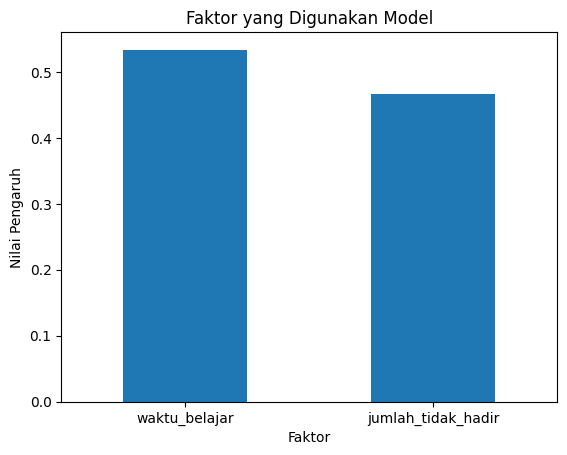

In [183]:
pengaruh.plot(
    kind="bar",
    x="faktor",
    y="nilai_pengaruh",
    legend=False
)

plt.title("Faktor yang Digunakan Model")
plt.xlabel("Faktor")
plt.ylabel("Nilai Pengaruh")
plt.xticks(rotation=0)
plt.show()

In [188]:
import pandas as pd

data_baru = pd.DataFrame([{'waktu_belajar': 3, 'jumlah_tidak_hadir': 2}])

prediksi_baru = model.predict(data_baru)[0]
peluang = model.predict_proba(data_baru)[0]
tingkat_keyakinan = peluang[prediksi_baru] * 100

hasil_teks = 'Lulus' if prediksi_baru == 1 else 'Belum Lulus'
print(f'Hasil prediksi: {hasil_teks}')
print(f'Tingkat keyakinan: {round(tingkat_keyakinan, 2)}%')

Hasil prediksi: Lulus
Tingkat keyakinan: 73.67%


In [187]:
import joblib

joblib.dump(model, 'model_kelulusan.pkl')
print('Model berhasil disimpan sebagai model_kelulusan.pkl')

Model berhasil disimpan sebagai model_kelulusan.pkl


## Unduh Model untuk Streamlit
Jalankan sel ini untuk mengunduh file model ke komputer Anda secara otomatis.

In [190]:
from google.colab import files

files.download('model_kelulusan.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Bagian Akhir: Export Model
Model yang telah dilatih disimpan dalam format `.pkl` agar dapat digunakan kembali di aplikasi web (Streamlit) tanpa harus melatih ulang.

In [191]:
from google.colab import files

# Mengunduh file model untuk digunakan di Streamlit
files.download('model_kelulusan.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [209]:
%%writefile app.py
import streamlit as st
import joblib
import pandas as pd

# Konfigurasi Halaman
st.set_page_config(page_title="Prediksi Kelulusan Pelajar", layout="centered")

# Load Model
@st.cache_resource
def load_model():
    return joblib.load('model_kelulusan.pkl')

try:
    model = load_model()
except:
    st.error("File model_kelulusan.pkl tidak ditemukan. Pastikan file sudah diunggah ke GitHub.")

# Antarmuka Pengguna
st.title("✏️ Prediksi Kelulusan Pelajar")
st.write("Aplikasi ini memprediksi status kelulusan berdasarkan kebiasaan belajar.")

with st.form("prediction_form"):
    st.subheader("Input Data Siswa")

    waktu_belajar = st.slider(
        "Waktu Belajar Mingguan",
        min_value=1, max_value=4, value=2,
        help="1: <2 jam, 2: 2-5 jam, 3: 5-10 jam, 4: >10 jam"
    )

    absences = st.number_input(
        "Jumlah Ketidakhadiran (Absensi)",
        min_value=0, max_value=100, value=0
    )

    submit = st.form_submit_button("Prediksi Sekarang")

if submit:
    # Menyiapkan data untuk prediksi
    input_data = pd.DataFrame([{
        'waktu_belajar': waktu_belajar,
        'jumlah_tidak_hadir': absences
    }])

    # Melakukan prediksi
    prediksi = model.predict(input_data)[0]
    peluang = model.predict_proba(input_data)[0]

    st.divider()

    if prediksi == 1:
        st.success(f"### Hasil: LULUS")
        st.write(f"Tingkat keyakinan model: {peluang[1]*100:.2f}%")
    else:
        st.warning(f"### Hasil: BELUM LULUS")
        st.write(f"Tingkat keyakinan model: {peluang[0]*100:.2f}%")

st.info("Catatan: Hasil ini adalah prediksi berdasarkan data historis dan bukan keputusan resmi.")

Overwriting app.py


In [203]:
!cat app.py


import streamlit as st

st.set_page_config(
    page_title="Prediksi Kelulusan Pelajar",
    layout="centered"
)

st.title("Prediksi Kelulusan Pelajar")

st.write(
    """
    Aplikasi ini digunakan untuk memperkirakan kelulusan
    berdasarkan waktu belajar dan jumlah ketidakhadiran.
    """
)

st.info(
    """
    Hasil aplikasi hanya berupa perkiraan dan bukan keputusan
    kelulusan resmi.
    """
)


In [204]:
!python -m py_compile app.py

In [205]:
import joblib
import pandas as pd

model_uji = joblib.load("model_kelulusan.pkl")

data_uji = pd.DataFrame([
    {
        "waktu_belajar": 3,
        "jumlah_tidak_hadir": 2
    }
])

hasil = model_uji.predict(data_uji)[0]

print(
    "Hasil:",
    "Lulus" if hasil == 1 else "Belum Lulus"
)

Hasil: Lulus


In [207]:
from google.colab import files

with open('requirements.txt', 'w') as f:
    f.write('streamlit\nscikit-learn\npandas\njoblib')

files.download('app.py')
files.download('model_kelulusan.pkl')
files.download('requirements.txt')
files.download('dataset_kelulusan.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Membuat File URL Aplikasi
Sesuai instruksi UTS nomor 10, sel ini akan membuat file `url_aplikasi.txt` yang berisi data diri dan tautan proyek Anda.

In [208]:
konten_url = """Nama: Deni Trio Saputra
NIM: 24110300009
Kelas: AI03

URL Streamlit:
[TEMPEL_URL_STREAMLIT_DI_SINI]

URL GitHub:
[TEMPEL_URL_GITHUB_DI_SINI]

Sumber Dataset:
https://archive.ics.uci.edu/dataset/320/student+performance
"""

with open('url_aplikasi.txt', 'w') as f:
    f.write(konten_url)

print("File url_aplikasi.txt berhasil dibuat.")
from google.colab import files
files.download('url_aplikasi.txt')

File url_aplikasi.txt berhasil dibuat.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>